# Week 1: Neural Network on MNIST

## Summer of Code - Deep Learning

This notebook implements a simple neural network using PyTorch 
to classify handwritten digits from the MNIST dataset.

### Objective
- Load the MNIST dataset
- Build a neural network
- Train the model using backpropagation
- Evaluate accuracy on test data

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.1+cpu


In [3]:
# Transform images into tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%


Training samples: 60000
Testing samples: 10000


In [4]:
from torch.utils.data import DataLoader

# Creating batches
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Number of training batches: 938
Number of testing batches: 157


In [5]:
# Creating a simple Neural Network

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


# Create model
model = NeuralNetwork()

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [6]:
# Loss function and optimizer

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created")

Loss function and optimizer created


In [8]:
# Training the model

epochs = 5

losses = []

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = loss_function(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.0443
Epoch [2/5], Loss: 0.0364
Epoch [3/5], Loss: 0.0282
Epoch [4/5], Loss: 0.0232
Epoch [5/5], Loss: 0.0221


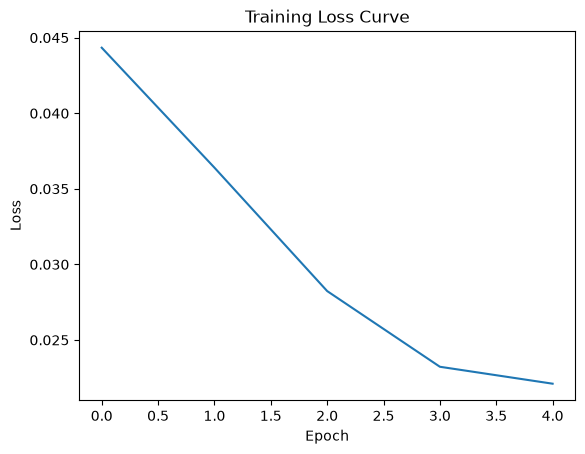

In [9]:
# Plot training loss

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [10]:
# Testing the model accuracy

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.77%


## Model Evaluation

The trained neural network is evaluated on the MNIST test dataset.

Accuracy is calculated as:

Accuracy = (Correct Predictions / Total Predictions) × 100

The model achieved good performance after training for 5 epochs.

In [11]:
# Saving the trained model

torch.save(model.state_dict(), "mnist_neural_network.pth")

print("Model saved successfully!")

Model saved successfully!


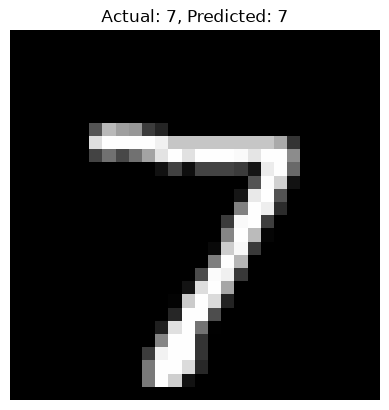

In [12]:
# Display one prediction

import matplotlib.pyplot as plt

image, label = test_dataset[0]

with torch.no_grad():
    output = model(image.unsqueeze(0))
    prediction = torch.argmax(output).item()

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual: {label}, Predicted: {prediction}")
plt.axis("off")
plt.show()

# Conclusion

In this project, a simple neural network was implemented using PyTorch
to classify handwritten digits from the MNIST dataset.

The model was trained using:
- Forward propagation
- Cross entropy loss
- Adam optimizer
- Backpropagation

The trained model achieved good accuracy on unseen test data.